# UASD with other models

Deze notebook gebruikt de BEATs-implementatie uit `unilm/beats` voor de challenge.
De globale workflow is: model laden, optioneel TSE gebruiken, embeddings extraheren en visualiseren.
Voor je begint:
1. Clone `https://github.com/microsoft/unilm/tree/master/beats`.
2. Download `BEATs_iter3_plus_AS2M.pt` via de README van die repo.

In [3]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchaudio
from peft import LoraConfig, get_peft_model
from scipy.io import wavfile
from sklearn.decomposition import PCA

sys.path.append(r"C:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\unilm\beats") # zelf aanpassen naar jouw pad van de geclonede BEATs repository 
from BEATs import BEATs, BEATsConfig

c:\Users\20202299\AppData\Local\anaconda3\envs\sorama\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Helper functions
Hier definiëren we hulpfuncties voor spectrogram-conversie, ruis toevoegen en audio-enhancement die later in training/extractie worden hergebruikt.

In [4]:
STFT_N_FFT = 512
STFT_HOP_LENGTH = 160

# STFT settings used by helper functions and TSE preprocessing.

def waveform_to_spec(waveform):
    """Convert a waveform tensor to STFT magnitude."""
    spec = torch.stft(
        waveform,
        n_fft=STFT_N_FFT,
        hop_length=STFT_HOP_LENGTH,
        return_complex=True,
    )
    return torch.abs(spec)


def spec_to_waveform(spec, phase, length):
    """Reconstruct waveform from magnitude and phase tensors."""
    complex_spec = spec * torch.exp(1j * phase)
    waveform = torch.istft(
        complex_spec,
        n_fft=STFT_N_FFT,
        hop_length=STFT_HOP_LENGTH,
        length=length,
    )
    return waveform


def create_noisy_sample(waveform):
    """Add random Gaussian noise for denoising training pairs."""
    noise_level = torch.empty(1).uniform_(0.01, 0.05).item()
    noise = noise_level * torch.randn_like(waveform)
    return waveform + noise


def enhance_audio(waveform):
    """Enhance a waveform with the trained TSE model in the STFT domain."""
    spec = torch.stft(
        waveform,
        n_fft=STFT_N_FFT,
        hop_length=STFT_HOP_LENGTH,
        return_complex=True,
    )

    magnitude = torch.abs(spec)
    phase = torch.angle(spec)

    # Model expects [batch, channel, freq, time].
    magnitude = magnitude.unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        enhanced_mag = tse_model(magnitude).squeeze(0).squeeze(0)

    enhanced_wave = torch.istft(
        enhanced_mag * torch.exp(1j * phase),
        n_fft=STFT_N_FFT,
        hop_length=STFT_HOP_LENGTH,
        length=waveform.shape[-1],
    )

    return enhanced_wave

## Configuration block
In deze sectie zet je de belangrijkste experimentinstellingen (mode, sample rate, batch size, epochs en smoke-test opties).

In [14]:
APPLY_AUGMENTATION = True
FEATURE_EXTRACTOR_MODE = "lora"  # "frozen", "lora", "last_layer" or "adapter"
USE_TSE = True
TARGET_SAMPLE_RATE = 16000

BATCH_SIZE = 32
EPOCHS = 50

ADAPTER_DIM = 64  # Bottleneck size used when FEATURE_EXTRACTOR_MODE == "adapter"

QUICK_SMOKE_TEST = False  # True = faster TSE smoke run (subset + 1 epoch)
TSE_SMOKE_MAX_FILES = 128  # Used only when QUICK_SMOKE_TEST is True

## Load model
Hier laden we BEATs vanuit de geclonede repo en daarna de checkpoint-weights.
Als CUDA beschikbaar is, wordt automatisch de GPU gebruikt; anders CPU.
Na deze cel staat het basismodel klaar voor feature-extractie of fine-tuning.

In [15]:
checkpoint_path = "BEATs_iter3_plus_AS2M.pt"
checkpoint = torch.load(checkpoint_path, map_location="cpu")

cfg = BEATsConfig(checkpoint["cfg"])
model = BEATs(cfg)
model.load_state_dict(checkpoint["model"])

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

c:\Users\20202299\AppData\Local\anaconda3\envs\sorama\lib\site-packages\torch\nn\utils\weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


## TSE model
Deze sectie bouwt en traint een eenvoudige speech/audio enhancement module die ruis kan onderdrukken voor robuustere features.

In [16]:
# Optional: build a DataLoader for TSE training.
TSE_TRAIN_FOLDER = r"C:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\data\dcase2023t2\dev_data\raw\bearing\train"
TSE_SEGMENT_SECONDS = 1.0

quick_smoke_test = globals().get("QUICK_SMOKE_TEST", False)
smoke_max_files = globals().get("TSE_SMOKE_MAX_FILES", 128)
TSE_MAX_FILES = smoke_max_files if quick_smoke_test else None

if quick_smoke_test:
    print(f"Quick smoke mode enabled: limiting TSE loader to first {TSE_MAX_FILES} files.")

if "loader" in globals():
    del loader


def _load_waveform_for_tse(file_path, target_sr):
    """Load WAV from disk, convert to mono, and resample to target_sr."""
    try:
        waveform, sr = torchaudio.load(file_path)
    except RuntimeError:
        sr, data = wavfile.read(file_path)
        data = np.asarray(data)

        if np.issubdtype(data.dtype, np.integer):
            max_val = np.iinfo(data.dtype).max
            data = data.astype(np.float32) / float(max_val)
        else:
            data = data.astype(np.float32)

        if data.ndim == 1:
            waveform = torch.from_numpy(data).unsqueeze(0)
        else:
            waveform = torch.from_numpy(data.T)

        sr = int(sr)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0)
    else:
        waveform = waveform.squeeze(0)

    if sr != target_sr:
        waveform = torchaudio.functional.resample(
            waveform.unsqueeze(0),
            sr,
            target_sr,
        ).squeeze(0)

    return waveform


class TSEWaveformDataset(torch.utils.data.Dataset):
    """Dataset that returns fixed-length waveform segments as tuples."""

    def __init__(self, file_paths, target_sr, segment_seconds=1.0):
        self.file_paths = file_paths
        self.target_sr = target_sr
        self.segment_length = max(1, int(segment_seconds * target_sr))

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        waveform = _load_waveform_for_tse(file_path, self.target_sr)

        # Random crop for long files; right-pad short files.
        if waveform.shape[0] >= self.segment_length:
            max_start = waveform.shape[0] - self.segment_length
            start = torch.randint(0, max_start + 1, (1,)).item() if max_start > 0 else 0
            waveform = waveform[start : start + self.segment_length]
        else:
            pad_len = self.segment_length - waveform.shape[0]
            waveform = torch.nn.functional.pad(waveform, (0, pad_len))

        return (waveform,)


wav_paths = []
if os.path.isdir(TSE_TRAIN_FOLDER):
    for root, _, files in os.walk(TSE_TRAIN_FOLDER):
        for file_name in files:
            if file_name.lower().endswith(".wav"):
                wav_paths.append(os.path.join(root, file_name))
else:
    print(f"TSE_TRAIN_FOLDER does not exist: {TSE_TRAIN_FOLDER}")

wav_paths.sort()
if TSE_MAX_FILES is not None:
    wav_paths = wav_paths[:TSE_MAX_FILES]

if len(wav_paths) == 0:
    print("No WAV files found. Update TSE_TRAIN_FOLDER and rerun this cell.")
else:
    dataset = TSEWaveformDataset(
        wav_paths,
        target_sr=TARGET_SAMPLE_RATE,
        segment_seconds=TSE_SEGMENT_SECONDS,
    )
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=False,
    )
    print(f"Created loader with {len(dataset)} files and batch size {BATCH_SIZE}.")

Created loader with 1000 files and batch size 32.


In [8]:
class TSEModel(nn.Module):
    """Lightweight encoder-decoder for magnitude-spectrogram denoising."""

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 8, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, 2, stride=2, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        """Map noisy magnitude spectrograms to cleaned estimates."""
        z = self.encoder(x)
        out = self.decoder(z)
        return out


tse_model = TSEModel().to(device)

optimizer = torch.optim.Adam(tse_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

quick_smoke_test = globals().get("QUICK_SMOKE_TEST", False)
epochs = 1 if quick_smoke_test else 10

if quick_smoke_test:
    print("Quick smoke mode enabled: TSE training for 1 epoch.")

if not USE_TSE:
    print("USE_TSE is False, skipping TSE training.")
elif "loader" not in globals():
    print("No 'loader' found. Define a DataLoader named 'loader' before training TSE.")
else:
    for epoch in range(epochs):
        total_loss = 0.0

        for batch in loader:
            clean_wave = batch[0].to(device)
            noisy_wave = create_noisy_sample(clean_wave)

            # Supervise denoising in the magnitude-spectrogram domain.
            clean_spec = waveform_to_spec(clean_wave).unsqueeze(1).to(device)
            noisy_spec = waveform_to_spec(noisy_wave).unsqueeze(1).to(device)

            optimizer.zero_grad()
            pred = tse_model(noisy_spec)
            loss = loss_fn(pred, clean_spec)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print("Epoch", epoch, "Loss", total_loss)

Epoch 0 Loss 4.296922840178013
Epoch 1 Loss 3.234291300177574
Epoch 2 Loss 2.1936156563460827
Epoch 3 Loss 1.2239529732614756
Epoch 4 Loss 1.0721575915813446
Epoch 5 Loss 1.0507888663560152
Epoch 6 Loss 1.059116579592228
Epoch 7 Loss 1.0522812809795141
Epoch 8 Loss 1.0487848836928606
Epoch 9 Loss 1.0688527543097734


## Preprocess data
Hier wordt audio ingelezen, eventueel geaugmenteerd en naar een consistente vorm gebracht vóór feature-extractie.
Dit zorgt dat korte clips, sample-rates en kanaalverschillen uniform behandeld worden.

In [17]:
MIN_WAVEFORM_SAMPLES = 400


def augment_waveform(
    waveform,
    sample_rate,
    noise_prob=0.5,
    gain_prob=0.5,
    shift_prob=0.5,
    dropout_prob=0.3,
):
    """Apply simple time-domain augmentations to improve robustness."""
    if torch.rand(1).item() < noise_prob:
        noise_std = torch.empty(1).uniform_(0.001, 0.01).item()
        waveform = waveform + noise_std * torch.randn_like(waveform)

    if torch.rand(1).item() < gain_prob:
        gain = torch.empty(1).uniform_(0.8, 1.2).item()
        waveform = waveform * gain

    if torch.rand(1).item() < shift_prob:
        max_shift = int(0.1 * sample_rate)
        shift = torch.randint(-max_shift, max_shift + 1, (1,)).item()
        waveform = torch.roll(waveform, shifts=shift, dims=0)

    if torch.rand(1).item() < dropout_prob:
        drop_len = int(0.02 * sample_rate)
        start = torch.randint(0, max(1, waveform.shape[0] - drop_len), (1,)).item()
        waveform[start : start + drop_len] = 0

    waveform = torch.clamp(waveform, -1.0, 1.0)
    return waveform


def _load_wav_with_scipy(file_path):
    """Fallback WAV loader when torchaudio backend is unavailable."""
    sr, data = wavfile.read(file_path)
    data = np.asarray(data)

    if np.issubdtype(data.dtype, np.integer):
        max_val = np.iinfo(data.dtype).max
        data = data.astype(np.float32) / float(max_val)
    else:
        data = data.astype(np.float32)

    if data.ndim == 1:
        waveform = torch.from_numpy(data).unsqueeze(0)  # [1, time]
    else:
        waveform = torch.from_numpy(data.T)  # [channels, time]

    return waveform, int(sr)


def load_audio(file_path, target_sr=16000, apply_augment=False):
    """Load audio, enforce mono/target sample rate, and optionally augment."""
    try:
        waveform, sr = torchaudio.load(file_path)
    except RuntimeError:
        waveform, sr = _load_wav_with_scipy(file_path)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0)
    else:
        waveform = waveform.squeeze(0)

    if sr != target_sr:
        waveform = torchaudio.functional.resample(
            waveform.unsqueeze(0),
            sr,
            target_sr,
        ).squeeze(0)

    if waveform.shape[0] < MIN_WAVEFORM_SAMPLES:
        pad_len = MIN_WAVEFORM_SAMPLES - waveform.shape[0]
        waveform = torch.nn.functional.pad(waveform, (0, pad_len))

    if apply_augment:
        waveform = augment_waveform(waveform, target_sr)

    return waveform


def extract_beats_embedding(waveform):
    """Extract a single clip embedding by mean-pooling BEATs frame features."""
    waveform = waveform.to(device)
    with torch.no_grad():
        features, _ = model.extract_features(waveform.unsqueeze(0))  # [1, T, 768]
        clip_embedding = features.mean(dim=1).squeeze(0).cpu().numpy()  # [768]
    return clip_embedding

## Feature extractor training
In deze stap kies je hoe BEATs wordt gebruikt: volledig bevroren, laatste laag trainen, LoRA, of adapter-gebaseerde finetuning.

In [18]:
if FEATURE_EXTRACTOR_MODE == "frozen":
    print("Using frozen BEATs")

    for param in model.parameters():
        param.requires_grad = False

elif FEATURE_EXTRACTOR_MODE == "last_layer":
    print("Fine-tuning last transformer layers")

    for param in model.parameters():
        param.requires_grad = False

    for param in model.encoder.layers[-1].parameters():
        param.requires_grad = True

elif FEATURE_EXTRACTOR_MODE == "lora":
    print("Using LoRA adaptation")

    lora_config = LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=0.1,
        bias="none",
    )

    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

elif FEATURE_EXTRACTOR_MODE == "adapter":
    print("Using bottleneck adapters")

    for param in model.parameters():
        param.requires_grad = False

    class BottleneckAdapter(nn.Module):
        """Residual bottleneck adapter: down-project, activate, then up-project."""

        def __init__(self, hidden_dim, adapter_dim=64):
            super().__init__()
            self.down_proj = nn.Linear(hidden_dim, adapter_dim)
            self.act = nn.ReLU()
            self.up_proj = nn.Linear(adapter_dim, hidden_dim)

            # Start near-identity so adapters do not change features before training.
            nn.init.zeros_(self.up_proj.weight)
            nn.init.zeros_(self.up_proj.bias)

        def forward(self, x):
            return x + self.up_proj(self.act(self.down_proj(x)))

    class BEATsWithAdapters(nn.Module):
        """Wrapper that injects adapter layers into BEATs feature outputs."""

        def __init__(self, beats_model, hidden_dim, adapter_dim=64):
            super().__init__()
            self.beats_model = beats_model
            self.adapter = BottleneckAdapter(hidden_dim, adapter_dim=adapter_dim)

        def extract_features(self, *args, **kwargs):
            """Run BEATs feature extraction and adapt frame-level representations."""
            features, padding_mask = self.beats_model.extract_features(*args, **kwargs)
            features = self.adapter(features)
            return features, padding_mask

        def forward(self, *args, **kwargs):
            return self.beats_model(*args, **kwargs)

    adapter_dim = int(globals().get("ADAPTER_DIM", 64))
    hidden_dim = int(getattr(cfg, "encoder_embed_dim", 768))

    model = BEATsWithAdapters(
        model,
        hidden_dim=hidden_dim,
        adapter_dim=adapter_dim,
    ).to(device)

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {trainable_params}/{total_params}")

else:
    raise ValueError(
        "FEATURE_EXTRACTOR_MODE must be one of: 'frozen', 'last_layer', 'lora', 'adapter'."
    )

Using LoRA adaptation
trainable params: 294,912 || all params: 90,606,704 || trainable%: 0.3255


## Embeddings uit één machine halen (duurt ±10 min)
Het BEATs-model extraheert 768 features per clip. Deze embeddings kun je daarna in een classifier gebruiken.
Deze cel loopt door alle audiofiles en schrijft per clip een `.npy` embedding weg in dezelfde mapstructuur.

In [19]:
from config import iter_all_data, get_features_path, get_train_features_path, get_test_features_path
import numpy as np

# 1. Define the model name for the directory structure
# This ensures features are saved in /features/Frozen_BEATs/...
model_used = f"{FEATURE_EXTRACTOR_MODE.capitalize()}" 

# Process all machines across all years defined in config.py
for year, machine, input_folder in iter_all_data():
    output_folder = get_features_path(model_used, year, machine, dataset="dev")
    print(f"\n Processing {year} - {machine}")
    print(f"Input:  {input_folder}")
    print(f"Output: {output_folder}")

    # ========== TRAIN FEATURES ==========
    train_input = input_folder / "train"
    if train_input.exists():
        train_output = get_train_features_path(model_used, year, machine, dataset="dev")
        
        # Check if train extraction is already done (standard DCASE train set ~1000 files)
        existing_train = list(train_output.rglob("*.npy"))
        if len(existing_train) >= 1000:
            print(f"Skipping train - {len(existing_train)} train features already present")
        else:
            train_wav_files = list(train_input.glob("**/*.wav"))
            if not train_wav_files:
                print(f"No train .wav files found")
            else:
                print(f"Processing train: Found {len(train_wav_files)} audio files")

                train_processed = 0
                for wav_file in train_wav_files:
                    try:
                        # Load using the specialized load_audio in UASD_EXTRA
                        waveform = load_audio(str(wav_file)) 
                        
                        # Apply TSE enhancement if enabled in your config block
                        if USE_TSE:
                            waveform = enhance_audio(waveform)
                            
                        embedding = extract_beats_embedding(waveform)

                        # Create output path mirroring the input subfolder structure
                        relative_path = wav_file.relative_to(train_input)
                        out_file = train_output / relative_path.with_suffix('.npy')
                        out_file.parent.mkdir(parents=True, exist_ok=True)

                        # Save as numpy array
                        np.save(out_file, embedding)
                        train_processed += 1

                    except Exception as e:
                        print(f"Error processing {wav_file}: {e}")

                print(f"Processed {train_processed}/{len(train_wav_files)} train files")
    else:
        print(f"No train folder found")

    # ========== TEST FEATURES ==========
    test_input = input_folder / "test"
    if test_input.exists():
        test_output = get_test_features_path(model_used, year, machine, dataset="dev")
        
        # Check if test extraction is already done
        existing_test = list(test_output.rglob("*.npy"))
        if len(existing_test) >= 100:
            print(f"Skipping test - {len(existing_test)} test features already present")
        else:
            test_wav_files = list(test_input.glob("**/*.wav"))
            if not test_wav_files:
                print(f"No test .wav files found")
            else:
                print(f"Processing test: Found {len(test_wav_files)} audio files")

                test_processed = 0
                for wav_file in test_wav_files:
                    try:
                        waveform = load_audio(str(wav_file))
                        
                        if USE_TSE:
                            waveform = enhance_audio(waveform)
                            
                        embedding = extract_beats_embedding(waveform)

                        relative_path = wav_file.relative_to(test_input)
                        out_file = test_output / relative_path.with_suffix('.npy')
                        out_file.parent.mkdir(parents=True, exist_ok=True)

                        np.save(out_file, embedding)
                        test_processed += 1

                    except Exception as e:
                        print(f"Error processing {wav_file}: {e}")

                print(f"Processed {test_processed}/{len(test_wav_files)} test files")
    else:
        print(f"No test folder found")

print("\n All feature extraction for UASD_EXTRA completed")


 Processing dcase2023t2 - ToyCar
Input:  c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\data\dcase2023t2\dev_data\raw\ToyCar
Output: c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\features\Lora\dcase2023t2_features\dev_features\raw_features\ToyCar_features
Processing train: Found 1000 audio files
Processed 1000/1000 train files
Processing test: Found 200 audio files
Processed 200/200 test files

 Processing dcase2023t2 - ToyTrain
Input:  c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\data\dcase2023t2\dev_data\raw\ToyTrain
Output: c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\features\Lora\dcase2023t2_features\dev_features\raw_features\ToyTrain_features
Processing train: Found 1000 audio files


KeyboardInterrupt: 

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from config import iter_all_data, get_features_path, get_train_features_path, get_test_features_path, get_pca_path
import pickle
import os
            
# Function to apply PCA to a single machine's features
def apply_pca_to_machine(year, machine, features_path):
    """Apply PCA to features of a specific machine and save results"""

    # Define the output directory and the "flag" file
    pca_dir = get_pca_path(model_used, year, machine, dataset="dev")
    flag_file = pca_dir / "pca_model.pkl"

    if flag_file.exists():
        print(f"Skipping {year}-{machine}: PCA results already exist.")
        # Optional: Load and return the existing data if you still need it in pca_results{}
        # X_train_pca = np.load(pca_dir / "train_features_pca.npy")
        # with open(flag_file, 'rb') as f:
        #     pca_reduced = pickle.load(f)
        # return X_train_pca, pca_reduced
        return None, "exists" 

    # Load training features (for fitting PCA)
    train_features_path = get_train_features_path(model_used, year, machine, dataset="dev")
    if not train_features_path.exists():
        print(f"No train features found for {year}-{machine}")
        return None, None

    train_files = list(train_features_path.glob("**/*.npy"))
    if not train_files:
        print(f"No train feature files found for {year}-{machine}")
        return None, None

    print(f"Processing {len(train_files)} train features for {year}-{machine}")

    # Load train embeddings
    train_embeddings = []
    for file in train_files:
        try:
            emb = np.load(file)
            train_embeddings.append(emb)
        except Exception as e:
            print(f"Error loading train {file}: {e}")

    if not train_embeddings:
        print(f"No valid train embeddings for {year}-{machine}")
        return None, None

    X_train = np.vstack(train_embeddings)
    print(f"   Train shape: {X_train.shape}")

    # 1. Full PCA for variance analysis (on train data)
    pca_full = PCA()
    pca_full.fit(X_train)

    # 2. Apply PCA with 95% variance threshold (trained on train data)
    pca_reduced = PCA(n_components=0.95)
    X_train_pca = pca_reduced.fit_transform(X_train)

    print(f"   Train PCA shape: {X_train_pca.shape} (components: {pca_reduced.n_components_})")

    # 3. Apply trained PCA to test features if they exist
    test_features_path = get_test_features_path(model_used, year, machine, dataset="dev")
    X_test_pca = None
    if test_features_path.exists():
        test_files = list(test_features_path.glob("**/*.npy"))
        if test_files:
            test_embeddings = []
            for file in test_files:
                try:
                    emb = np.load(file)
                    test_embeddings.append(emb)
                except Exception as e:
                    print(f"Error loading test {file}: {e}")

            if test_embeddings:
                X_test = np.vstack(test_embeddings)
                X_test_pca = pca_reduced.transform(X_test)
                print(f"   Test PCA shape: {X_test_pca.shape}")

    # 4. Save PCA results
    pca_dir = get_pca_path(model_used, year, machine, dataset="dev")

    # Save train features
    np.save(pca_dir / "train_features_pca.npy", X_train_pca)

    # Save test features if available
    if X_test_pca is not None:
        np.save(pca_dir / "test_features_pca.npy", X_test_pca)

    # Save PCA model for future use
    with open(pca_dir / "pca_model.pkl", 'wb') as f:
        pickle.dump(pca_reduced, f)

    # Save explained variance info
    variance_info = {
        'explained_variance_ratio': pca_reduced.explained_variance_ratio_,
        'cumulative_variance': np.cumsum(pca_reduced.explained_variance_ratio_),
        'n_components': pca_reduced.n_components_,
        'train_original_shape': X_train.shape,
        'train_reduced_shape': X_train_pca.shape,
        'test_reduced_shape': X_test_pca.shape if X_test_pca is not None else None
    }
    np.save(pca_dir / "variance_info.npy", variance_info)

    return X_train_pca, pca_reduced

# Process all machines
print("Starting PCA processing for all machines...\n")

pca_results = {}
for year, machine, _ in iter_all_data():
    features_path = get_features_path(model_used, year, machine, dataset="dev")

    if not features_path.exists():
        print(f"Features directory not found: {features_path}")
        continue

    print(f"\n Processing {year} - {machine}")
    X_pca, pca_model = apply_pca_to_machine(year, machine, features_path)

    if X_pca is not None:
        pca_results[f"{year}_{machine}"] = {
            'features': X_pca,
            'model': pca_model,
            'path': features_path
        }

print(f"\n PCA completed for {len(pca_results)} machines")
print("PCA results saved in each machine's features/pca/ directory")

Starting PCA processing for all machines...


 Processing dcase2023t2 - ToyCar
Processing 1000 train features for dcase2023t2-ToyCar
   Train shape: (1000, 768)
   Train PCA shape: (1000, 66) (components: 66)
   Test PCA shape: (200, 66)

 Processing dcase2023t2 - ToyTrain
Processing 3 train features for dcase2023t2-ToyTrain
   Train shape: (3, 768)
   Train PCA shape: (3, 2) (components: 2)

 Processing dcase2023t2 - bearing
No train feature files found for dcase2023t2-bearing

 Processing dcase2023t2 - fan
No train feature files found for dcase2023t2-fan

 Processing dcase2023t2 - gearbox
No train feature files found for dcase2023t2-gearbox

 Processing dcase2023t2 - valve
No train feature files found for dcase2023t2-valve

 Processing dcase2024t2 - ToyCar
No train feature files found for dcase2024t2-ToyCar

 Processing dcase2024t2 - ToyTrain
No train feature files found for dcase2024t2-ToyTrain

 Processing dcase2024t2 - bearing
No train feature files found for dcase2024t2-bearing



## PCA Visualization of other models

Je kan

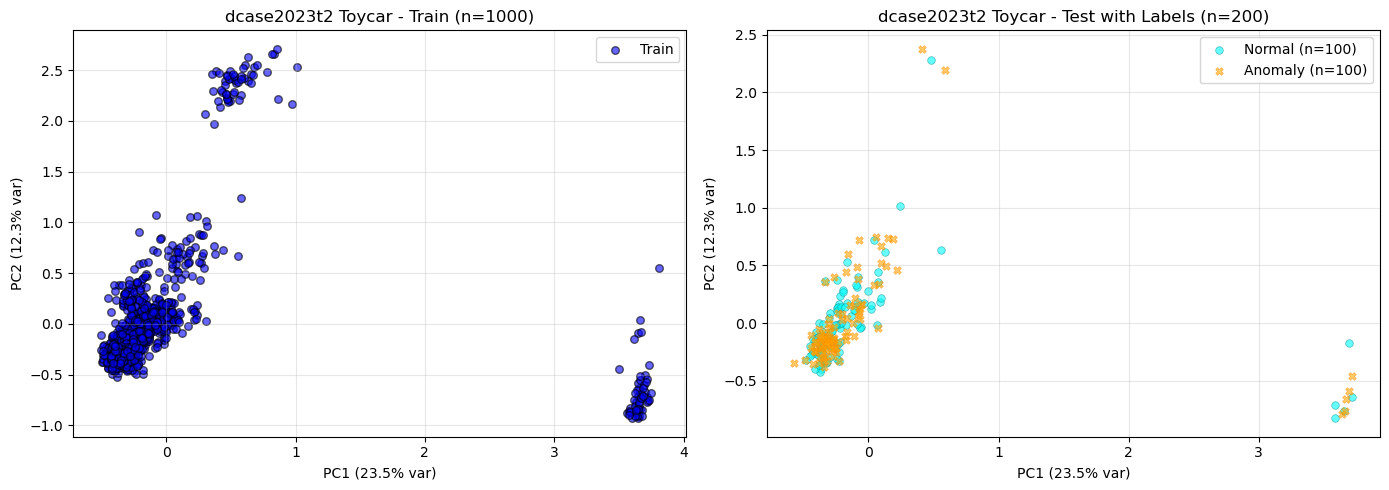

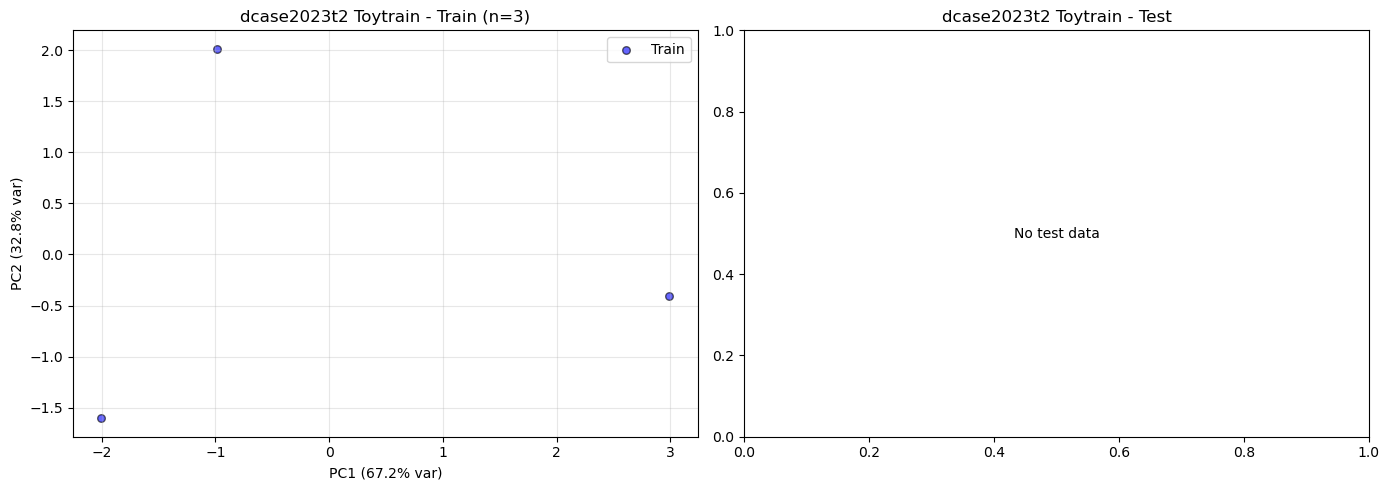

In [21]:
# Generate individual PCA scatterplots for each machine (train AND test)
import matplotlib.pyplot as plt
from config import iter_all_data, load_pca_results, get_test_features_path

def extract_label_from_filename(filename):
    """Extract 'normal' or 'anomaly' label from filename"""
    filename_lower = str(filename).lower()
    if 'anomaly' in filename_lower:
        return 1  # Anomaly
    elif 'normal' in filename_lower:
        return 0  # Normal
    else:
        return None  # Unknown label
    
for year, machine, _ in iter_all_data():
    X_train, variance_info_train = load_pca_results(model_used, year, machine, split="train")
    X_test, variance_info_test = load_pca_results(model_used, year, machine, split="test")
    
    if X_train is None and X_test is None:
        continue
    
    # Create figure with subplots for train and test
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    # Train subplot
    if X_train is not None:
        axs[0].scatter(X_train[:,0], X_train[:,1], alpha=0.6, s=30, color='blue', edgecolors='k', label='Train')
        axs[0].set_xlabel(f'PC1 ({variance_info_train["explained_variance_ratio"][0]:.1%} var)')
        axs[0].set_ylabel(f'PC2 ({variance_info_train["explained_variance_ratio"][1]:.1%} var)')
        axs[0].set_title(f'{year} {machine.title()} - Train (n={X_train.shape[0]})')
        axs[0].grid(True, alpha=0.3)
        axs[0].legend()
    else:
        axs[0].text(0.5, 0.5, 'No train data', ha='center', va='center')
        axs[0].set_title(f'{year} {machine.title()} - Train')
    
    # Test subplot
    if X_test is not None:
        # Extract labels from test filenames
        test_features_path = get_test_features_path(model_used, year, machine, dataset="dev")
        test_files = sorted(list(test_features_path.glob("**/*.npy")))
        
        test_labels = []
        for file in test_files:
            label = extract_label_from_filename(file.name)
            if label is not None:
                test_labels.append(label)
        
        # Color-code by labels if available
        if len(test_labels) == X_test.shape[0]:
            test_labels = np.array(test_labels)
            normal_mask = test_labels == 0
            anomaly_mask = test_labels == 1
            
            if np.sum(normal_mask) > 0:
                axs[1].scatter(X_test[normal_mask,0], X_test[normal_mask,1], alpha=0.6, s=30, 
                             color='cyan', edgecolors='darkcyan', linewidth=0.5, label=f'Normal (n={np.sum(normal_mask)})')
            if np.sum(anomaly_mask) > 0:
                axs[1].scatter(X_test[anomaly_mask,0], X_test[anomaly_mask,1], alpha=0.6, s=30,
                             color='orange', edgecolors='darkorange', linewidth=0.5, marker='X', label=f'Anomaly (n={np.sum(anomaly_mask)})')
        else:
            axs[1].scatter(X_test[:,0], X_test[:,1], alpha=0.6, s=30, color='red', edgecolors='k', label='Test')
        
        axs[1].set_xlabel(f'PC1 ({variance_info_test["explained_variance_ratio"][0]:.1%} var)')
        axs[1].set_ylabel(f'PC2 ({variance_info_test["explained_variance_ratio"][1]:.1%} var)')
        axs[1].set_title(f'{year} {machine.title()} - Test with Labels (n={X_test.shape[0]})')
        axs[1].grid(True, alpha=0.3)
        axs[1].legend()
    else:
        axs[1].text(0.5, 0.5, 'No test data', ha='center', va='center')
        axs[1].set_title(f'{year} {machine.title()} - Test')
    
    plt.tight_layout()
    plt.show()

## KNN classifier

In [26]:
from sklearn.neighbors import NearestNeighbors
import pickle
from pathlib import Path

class KNNAnomalyDetector:
    """
    KNN-based anomaly detection using distance to k-th nearest neighbor.
    - Training: Uses normal audio features to learn the data distribution
    - Detection: Points far from their neighbors (distance > threshold) are flagged as anomalies
    """
    
    def __init__(self, k=5, threshold_percentile=95):
        """
        Args:
            k: Number of nearest neighbors to use
            threshold_percentile: Percentile of training distances to use as threshold (default: 95th percentile)
        """
        self.k = k
        self.threshold_percentile = threshold_percentile
        self.knn = None
        self.threshold = None
        self.training_distances = None
        
    def fit(self, X_train):
        """
        Fit the detector on normal (training) data.
        Calculates distance to k-th neighbor and sets anomaly threshold.
        
        Args:
            X_train: Training features (n_samples, n_features) - should be normal data
        """
        
        # Fit KNN on training data
        self.knn = NearestNeighbors(n_neighbors=self.k+1)  # +1 because it includes the point itself
        self.knn.fit(X_train)
        
        # Get distances to k-th nearest neighbor for all training points
        distances, indices = self.knn.kneighbors(X_train)
        self.training_distances = distances[:, self.k]  # Distance to k-th neighbor (skip 1st which is self)
        
        # Set threshold based on percentile
        self.threshold = np.percentile(self.training_distances, self.threshold_percentile)

    def predict(self, X_test):
        """
        Predict anomalies for test data.
        
        Args:
            X_test: Test features (n_samples, n_features)
            
        Returns:
            predictions: Array of 0 (normal) or 1 (anomaly)
            distances: Distance to k-th nearest neighbor for each point
        """
        if self.knn is None:
            raise ValueError("Detector must be fitted first using .fit()")
        
        distances, _ = self.knn.kneighbors(X_test)
        test_distances = distances[:, self.k]  # Distance to k-th neighbor
        
        # Classify as anomaly if distance > threshold
        predictions = (test_distances > self.threshold).astype(int)
        
        return predictions, test_distances
    
    def predict_single(self, x):
        """Predict anomaly for a single sample"""
        predictions, distances = self.predict(x.reshape(1, -1))
        return predictions[0], distances[0]

from sklearn.metrics import (confusion_matrix, classification_report, 
                             precision_recall_fscore_support, roc_auc_score, 
                             roc_curve, auc, precision_recall_curve)
import matplotlib.pyplot as plt

def load_test_data_with_labels(year, machine):
    """Load PCA-reduced test features and extract labels from filenames"""
    # Load PCA-reduced test features
    pca_dir = get_pca_path(model_used, year, machine, dataset="dev")
    pca_test_file = pca_dir / "test_features_pca.npy"
    
    if not pca_test_file.exists():
        return None, None, None
    
    # Load PCA-reduced features
    X_test_pca = np.load(pca_test_file)
    
    # Get labels from raw test filenames
    test_features_path = get_test_features_path(model_used, year, machine, dataset="dev")
    if not test_features_path.exists():
        return None, None, None
    
    # Get all .npy files (in same order as they were processed)
    test_files = sorted(list(test_features_path.glob("**/*.npy")))
    if not test_files:
        return None, None, None
    
    # Extract labels from filenames
    labels = []
    file_labels = []
    
    for file in test_files:
        label = extract_label_from_filename(file.name)
        if label is not None:
            labels.append(label)
            file_labels.append((file.name, label))
    
    if not labels or len(labels) != X_test_pca.shape[0]:
        return None, None, None
    
    y_test = np.array(labels)
    
    return X_test_pca, y_test, file_labels

results_summary = []

for year, machine, _ in iter_all_data():
    # Load training data
    X_train, _ = load_pca_results(model_used, year, machine, split="train")
    if X_train is None:
        # print(f"⚠️  No train data available")
        continue
    
    # Load test data with labels
    X_test, y_test, file_labels = load_test_data_with_labels(year, machine)
    if X_test is None:
        # print(f"⚠️  No labeled test data available")
        continue
    
    # Train detector
    detector = KNNAnomalyDetector(k=5, threshold_percentile=95)
    detector.fit(X_train)
    
    # Make predictions
    predictions, distances = detector.predict(X_test)
    
    # Compute metrics
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, predictions, average='binary')
    
    # ROC-AUC using distances (lower distance = more normal)
    y_scores = 1 - (distances / distances.max())  # Normalize distances to [0,1]
    roc_auc = roc_auc_score(y_test, y_scores)

    # Store results for summary
    results_summary.append({
        'machine': f"{year}-{machine}",
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'test_samples': X_test.shape[0]
    })
    
if results_summary:
    print(f"\n\n{'='*100}")
    print("SUMMARY: Performance Across All Machines")
    print(f"{'='*100}")
    print(f"{'Machine':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'ROC-AUC':<12} {'Samples':<10}")
    print(f"{'-'*100}")
    for result in results_summary:
        print(f"{result['machine']:<20} {result['precision']:<12.4f} {result['recall']:<12.4f} "
              f"{result['f1']:<12.4f} {result['roc_auc']:<12.4f} {result['test_samples']:<10}")
    print(f"{'-'*100}")
    avg_f1 = np.mean([r['f1'] for r in results_summary])
    avg_auc = np.mean([r['roc_auc'] for r in results_summary])
    print(f"{'Average':<20} {np.mean([r['precision'] for r in results_summary]):<12.4f} "
          f"{np.mean([r['recall'] for r in results_summary]):<12.4f} {avg_f1:<12.4f} {avg_auc:<12.4f}")
    print(f"{'='*100}")




SUMMARY: Performance Across All Machines
Machine              Precision    Recall       F1-Score     ROC-AUC      Samples   
----------------------------------------------------------------------------------------------------
dcase2023t2-ToyCar   0.3529       0.0600       0.1026       0.4921       200       
dcase2023t2-bearing  0.6389       0.2300       0.3382       0.4007       200       
----------------------------------------------------------------------------------------------------
Average              0.4959       0.1450       0.2204       0.4464      


## PCA visualization of other models for comparison

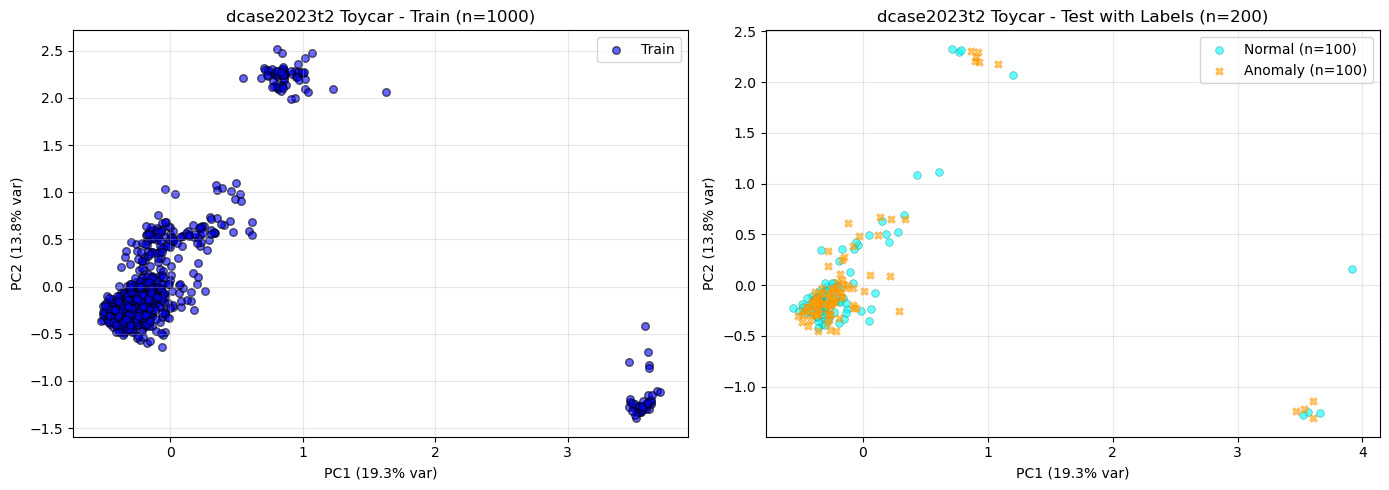

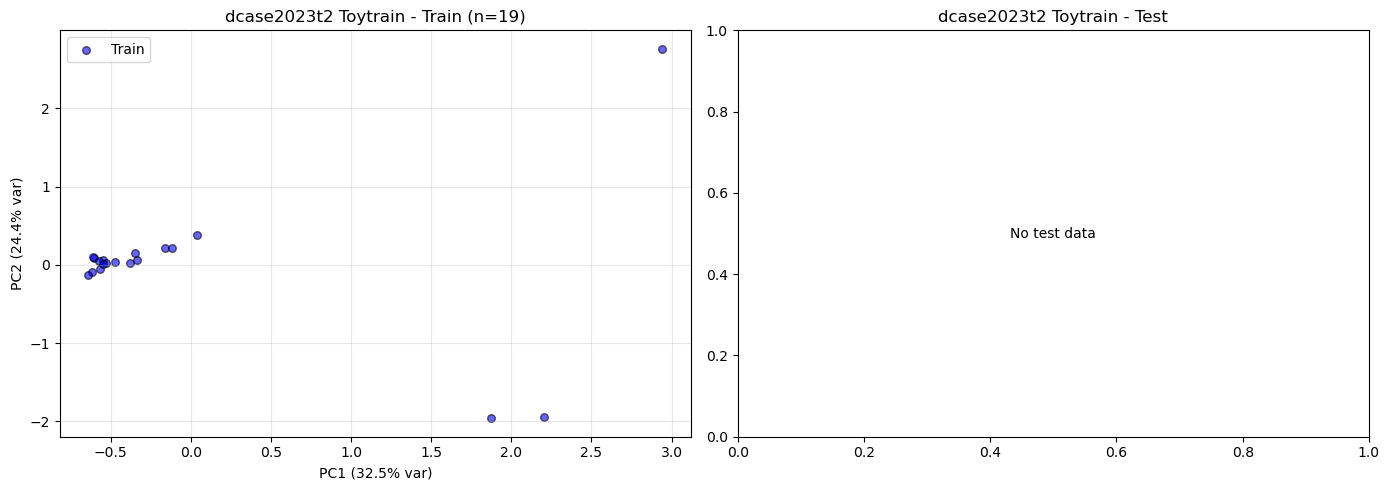

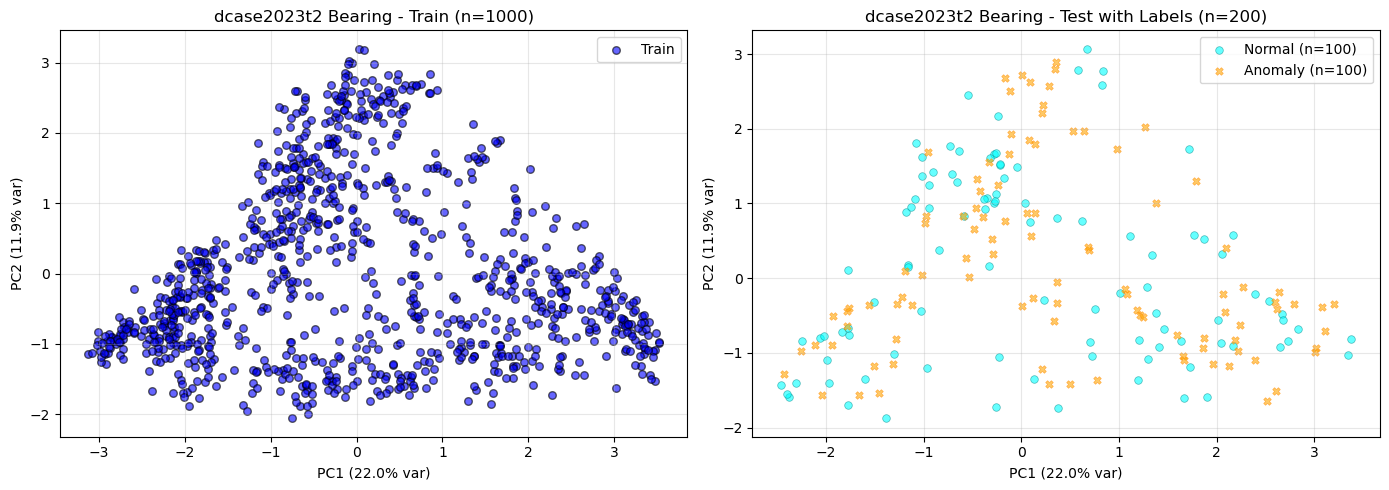

In [ ]:
# Generate individual PCA scatterplots for each machine (train AND test)

model_used = "frozen" # Update this if you want to visualize PCA results from a different feature extractor (e.g., "lora", "adapter", etc.)


import matplotlib.pyplot as plt
from config import iter_all_data, load_pca_results, get_test_features_path

def extract_label_from_filename(filename):
    """Extract 'normal' or 'anomaly' label from filename"""
    filename_lower = str(filename).lower()
    if 'anomaly' in filename_lower:
        return 1  # Anomaly
    elif 'normal' in filename_lower:
        return 0  # Normal
    else:
        return None  # Unknown label
    
for year, machine, _ in iter_all_data():
    X_train, variance_info_train = load_pca_results(model_used, year, machine, split="train")
    X_test, variance_info_test = load_pca_results(model_used, year, machine, split="test")
    
    if X_train is None and X_test is None:
        continue
    
    # Create figure with subplots for train and test
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    # Train subplot
    if X_train is not None:
        axs[0].scatter(X_train[:,0], X_train[:,1], alpha=0.6, s=30, color='blue', edgecolors='k', label='Train')
        axs[0].set_xlabel(f'PC1 ({variance_info_train["explained_variance_ratio"][0]:.1%} var)')
        axs[0].set_ylabel(f'PC2 ({variance_info_train["explained_variance_ratio"][1]:.1%} var)')
        axs[0].set_title(f'{year} {machine.title()} - Train (n={X_train.shape[0]})')
        axs[0].grid(True, alpha=0.3)
        axs[0].legend()
    else:
        axs[0].text(0.5, 0.5, 'No train data', ha='center', va='center')
        axs[0].set_title(f'{year} {machine.title()} - Train')
    
    # Test subplot
    if X_test is not None:
        # Extract labels from test filenames
        test_features_path = get_test_features_path(model_used, year, machine, dataset="dev")
        test_files = sorted(list(test_features_path.glob("**/*.npy")))
        
        test_labels = []
        for file in test_files:
            label = extract_label_from_filename(file.name)
            if label is not None:
                test_labels.append(label)
        
        # Color-code by labels if available
        if len(test_labels) == X_test.shape[0]:
            test_labels = np.array(test_labels)
            normal_mask = test_labels == 0
            anomaly_mask = test_labels == 1
            
            if np.sum(normal_mask) > 0:
                axs[1].scatter(X_test[normal_mask,0], X_test[normal_mask,1], alpha=0.6, s=30, 
                             color='cyan', edgecolors='darkcyan', linewidth=0.5, label=f'Normal (n={np.sum(normal_mask)})')
            if np.sum(anomaly_mask) > 0:
                axs[1].scatter(X_test[anomaly_mask,0], X_test[anomaly_mask,1], alpha=0.6, s=30,
                             color='orange', edgecolors='darkorange', linewidth=0.5, marker='X', label=f'Anomaly (n={np.sum(anomaly_mask)})')
        else:
            axs[1].scatter(X_test[:,0], X_test[:,1], alpha=0.6, s=30, color='red', edgecolors='k', label='Test')
        
        axs[1].set_xlabel(f'PC1 ({variance_info_test["explained_variance_ratio"][0]:.1%} var)')
        axs[1].set_ylabel(f'PC2 ({variance_info_test["explained_variance_ratio"][1]:.1%} var)')
        axs[1].set_title(f'{year} {machine.title()} - Test with Labels (n={X_test.shape[0]})')
        axs[1].grid(True, alpha=0.3)
        axs[1].legend()
    else:
        axs[1].text(0.5, 0.5, 'No test data', ha='center', va='center')
        axs[1].set_title(f'{year} {machine.title()} - Test')
    
    plt.tight_layout()
    plt.show()